In [2]:
import sys, os, gc
sys.path.insert(0, os.path.join('..'))   # project root on path

import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import wrds
import polars as pl
import polars.selectors as cs
import pyarrow
import config

from src.utils import generate_batches, train_val_test_split, split_batch
from sklearn.metrics import root_mean_squared_error, r2_score
from src.data_loading import *

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.float_format', '{:.4f}'.format)

---
# Functions

In [ ]:
# df_sp500 = fetch_sp500()
#gspc = pd.read_parquet(config.GSPC_PATH_RAW)
#gspc = gspc.dropna()
#gspc['date'] = pd.to_datetime(gspc['date'])
#gspc = gspc.drop(['vwretd', 'ewretd'], axis=1).reset_index(drop=True)
#gspc.to_parquet(config.GSPC_PATH_CLEAN)
#gspc.head()

,date,sprtrn
0,1962-07-03,0.0113
1,1962-07-05,0.0057
2,1962-07-06,-0.0113
3,1962-07-09,0.0068
4,1962-07-10,0.0115


In [202]:
def buy_and_hold(
    df: pd.DataFrame = None, 
    initial_capital: float = 1.0,
    start_date=None,
    end_date=None
) -> pd.DataFrame:
    
    """
    
    Get S&P 500 returns and create a benchmark to compare  with a strategy on a specific date range
    
    """
    
    if df is None:
        df = pd.read_parquet(config.GSPC_PATH_CLEAN)
    
        
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    
    mask = (df['date'] >= pd.to_datetime(start_date)) & (df['date'] <= pd.to_datetime(end_date))
    filtered = df.loc[mask, ['date', 'sprtrn']].reset_index(drop=True)
    
    anchor_date = pd.to_datetime(start_date) - pd.tseries.offsets.BDay(1)
    initial_row = pd.DataFrame({'date': [anchor_date], 'sprtrn': [0.0]})
    result = pd.concat([initial_row, filtered], ignore_index=True)
    
    pf = (result['sprtrn'] + 1).cumprod() * initial_capital
    date = result['date']
    
    return pf, date


def merge_and_batch(
    
) -> dict:
    
    
    """

    Read the features/cz/vix.parquet file and make the batch/split of the data

    """

    # 1. Load the clean parquet files
    features = pd.read_parquet(config.FEATURES_PATH_CLEAN).dropna()
    cz = pd.read_parquet(config.CZ_PATH_CLEAN)
    vix = pd.read_parquet(config.VIX_PATH_CLEAN)
    
    # 2. Merge VIX with CZ
    df_tmp = pd.merge(cz, vix, on='date')

    print(f'Number of unique PERMNO in dataset : {features['PERMNO'].nunique()}')

    # 3. Generate the split
    split_batch_dict = split_batch(features, 'PERMNO', 'date', df_to_join=[df_tmp], batch_number=config.BATCH_NUMBER, batch_size=config.BATCH_SIZE, overlap=False)
    
    
    # 4. Clear RAM space
    del features, cz, vix, df_tmp
    gc.collect()
    
    return split_batch_dict


def basic_lasso(
    split_batch_dict : dict
):
    
    """"

    Unique batch test

    """
    # 1. Loop on each batch
    TARGET = 'target'
    
    models = {}
    y_preds = {}
    
    for batch in split_batch_dict:
        
        y_train = split_batch_dict[batch]['train'][TARGET]
        X_train = split_batch_dict[batch]['train'].drop([TARGET, 'ret', 'mkt_ret'], axis=1)

        y_val = split_batch_dict[batch]['validation'][TARGET]
        X_val = split_batch_dict[batch]['validation'].drop([TARGET, 'ret', 'mkt_ret'], axis=1)
    
        # 1.1 Find the best alpha on a sample
        sample_idx = np.random.choice(len(X_train), size=50_000, replace=False)
        cv_model = LassoCV(cv=5, n_jobs=1)
        cv_model.fit(X_train.iloc[sample_idx], y_train.iloc[sample_idx])

        best_alpha = cv_model.alpha_
        print(f"Alpha optimal for {batch} : {best_alpha:.6f}")

        # 1.2. Train the model
        model = Lasso(alpha=best_alpha)
        model.fit(X_train, y_train)
        
        models[batch] = model
        
        y_pred = model.predict(X_val)
        y_preds[batch] = pd.DataFrame(y_pred, columns=['ret_pred'] ,index=y_val.index)

        print(f"R² train for {batch}: {r2_score(y_train, model.predict(X_train)):.4f}")
        print(f"R² val {batch}: {r2_score(y_val, y_pred):.4f}")

    return models, y_preds


def top_bottom(
    split_batch_dict : dict,
    y_preds : dict,
    threshold : float
):
    
    top_20s = {}
    bottom_20s = {}
    
    for batch, y_pred in y_preds.items():
        
        y_val = split_batch_dict[batch]['validation']['target']
        
        percentile_ranks = y_pred.groupby('date')['ret_pred'].transform(lambda x: x.rank(pct=True))

        is_top_20 = percentile_ranks >= threshold
        is_bottom_20 = percentile_ranks <= (1 - threshold)

        top_20_indexes = y_pred[is_top_20].index
        bottom_20_indexes = y_pred[is_bottom_20].index

        top_20_val_rows = pd.DataFrame(y_val.loc[top_20_indexes])
        bottom_20_val_rows = pd.DataFrame(y_val.loc[bottom_20_indexes])

        top_20 = top_20_val_rows.groupby('date').mean()
        bottom_20 = bottom_20_val_rows.groupby('date').mean()
        
        top_20s[batch] = top_20
        bottom_20s[batch] = bottom_20    
    
    return top_20s, bottom_20s


def portfolio_value(
    top_20s: dict,
    bottom_20s: dict,
    N: float = N,
    LONG_WEIGHT: float = LONG_WEIGHT,
    SHORT_WEIGHT: float = SHORT_WEIGHT,
    TRADING_COST: float = TRADING_COST,
    BORROW_COST_ANNUAL: float = BORROW_COST_ANNUAL,
    TRADING_DAYS: int = 252,
) -> tuple[dict, pd.DataFrame]:

    daily_borrow_cost = SHORT_WEIGHT * (BORROW_COST_ANNUAL / TRADING_DAYS)
    daily_trading_cost = (LONG_WEIGHT + SHORT_WEIGHT) * 2 * TRADING_COST

    portfolios = {}
    metrics_rows = []

    for batch in top_20s:
        top_20 = top_20s[batch]
        bottom_20 = bottom_20s[batch]

        daily_returns_pct = (
            LONG_WEIGHT  * (top_20  - TRADING_COST).squeeze()
            - SHORT_WEIGHT * (bottom_20 - TRADING_COST).squeeze()
            - daily_borrow_cost
            - daily_trading_cost
        ).reset_index(drop=True)

        portfolio = pd.concat(
            [pd.Series([N]), N * (1 + daily_returns_pct).cumprod()],
            ignore_index=True
        )
        portfolios[batch] = portfolio

        total_return   = portfolio.iloc[-1] / N - 1
        annualized_ret = (1 + total_return) ** (TRADING_DAYS / len(daily_returns_pct)) - 1
        volatility     = daily_returns_pct.std() * np.sqrt(TRADING_DAYS)
        sharpe         = annualized_ret / volatility
        max_drawdown   = ((portfolio / portfolio.cummax()) - 1).min()

        metrics_rows.append({
            'batch':               batch,
            'total_return':        total_return,
            'annualized_return':   annualized_ret,
            'volatility':          volatility,
            'sharpe_ratio':        sharpe,
            'max_drawdown':        max_drawdown,
        })

    metrics = pd.DataFrame(metrics_rows).set_index('batch')
    return portfolios, metrics


In [161]:
split_batch_dict = merge_and_batch()

Number of unique PERMNO in dataset : 6647
Total unique dates: 5104
  train: 2000-10-16 → 2014-12-29  (3572 dates, 70.0%)
  val  : 2014-12-30 → 2018-01-12  (766 dates, 15.0%)
  test : 2018-01-16 → 2021-01-29  (766 dates, 15.0%)
Total unique dates: 5104
  train: 2000-10-16 → 2014-12-29  (3572 dates, 70.0%)
  val  : 2014-12-30 → 2018-01-12  (766 dates, 15.0%)
  test : 2018-01-16 → 2021-01-29  (766 dates, 15.0%)
Total unique dates: 5103
  train: 2000-10-17 → 2014-12-30  (3572 dates, 70.0%)
  val  : 2014-12-31 → 2018-01-12  (765 dates, 15.0%)
  test : 2018-01-16 → 2021-01-29  (766 dates, 15.0%)
Total unique dates: 5103
  train: 2000-10-17 → 2014-12-30  (3572 dates, 70.0%)
  val  : 2014-12-31 → 2018-01-12  (765 dates, 15.0%)
  test : 2018-01-16 → 2021-01-29  (766 dates, 15.0%)
Total unique dates: 5104
  train: 2000-10-16 → 2014-12-29  (3572 dates, 70.0%)
  val  : 2014-12-30 → 2018-01-12  (766 dates, 15.0%)
  test : 2018-01-16 → 2021-01-29  (766 dates, 15.0%)


---
# Train and predict with each batch using Lasso

In [165]:
from sklearn.linear_model import LassoCV, Lasso, lasso_path

models, y_preds = basic_lasso(split_batch_dict)


Alpha optimal for batch_1 : 0.000016
R² train for batch_1: 0.0006
R² val batch_1: -0.0002
Alpha optimal for batch_2 : 0.000003
R² train for batch_2: 0.0014
R² val batch_2: -0.0006
Alpha optimal for batch_3 : 0.000003
R² train for batch_3: 0.0016
R² val batch_3: -0.0008
Alpha optimal for batch_4 : 0.000026
R² train for batch_4: 0.0004
R² val batch_4: -0.0000
Alpha optimal for batch_5 : 0.000004
R² train for batch_5: 0.0014
R² val batch_5: -0.0010


---
# Train and predict with each batch using LightGBM

In [1]:
import xgboost as xgb

---
# Post-processing strategy

In [208]:
top_20s, bottom_20s = top_bottom(split_batch_dict, y_preds, 0.80)

# ── Paramètres ────────────────────────────────────────────────────────────────
N                  = 1_000   # Capital initial
LONG_WEIGHT        = 0.50    # 50% long sur top 20%
SHORT_WEIGHT       = 0.10    # 10% short sur bottom 20%
TRADING_COST       = 0.001    # frais de transaction
BORROW_COST_ANNUAL = 0.01    # 1% coût d'emprunt annuel sur le short leg
TRADING_DAYS       = 252

portfolios, metrics = portfolio_value(top_20s, bottom_20s, N, LONG_WEIGHT, SHORT_WEIGHT, TRADING_COST, BORROW_COST_ANNUAL)
print(metrics.to_string(formatters={
    'total_return':      '{:+.2%}'.format,
    'annualized_return': '{:+.2%}'.format,
    'volatility':        '{:.2%}'.format,
    'sharpe_ratio':      '{:.2f}'.format,
    'max_drawdown':      '{:.2%}'.format,
}))

BH, date_range = buy_and_hold(pd.read_parquet(config.GSPC_PATH_CLEAN), initial_capital=N, start_date=y_preds['batch_1'].index.min()[0], end_date=y_preds['batch_1'].index.max()[0])

        total_return annualized_return volatility sharpe_ratio max_drawdown
batch                                                                      
batch_1      -59.05%           -25.48%      8.15%        -3.13      -59.52%
batch_2      -63.27%           -28.10%      7.94%        -3.54      -63.54%
batch_3      -63.51%           -28.29%      8.71%        -3.25      -63.62%
batch_4      -56.51%           -24.02%      8.31%        -2.89      -56.59%
batch_5      -70.35%           -33.00%      9.02%        -3.66      -70.55%


/var/folders/q1/4zz61hw135d8r5k_hlmg7rz00000gn/T/ipykernel_78467/3031388598.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(portfolios))


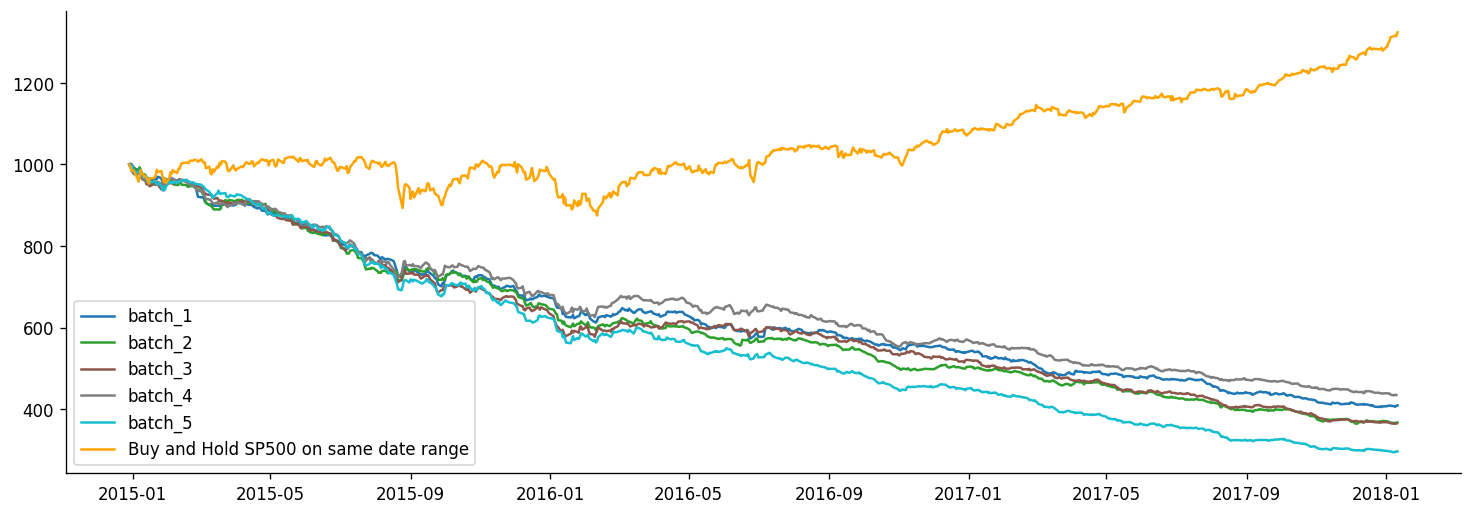

In [209]:
import matplotlib.cm as cm

cmap = cm.get_cmap('tab10', len(portfolios))
plt.figure(figsize=(15,5))
for i, (batch, portfolio) in enumerate(portfolios.items()):
    n = min(len(date_range), len(portfolio))
    plt.plot(date_range[:n], portfolio[:n], color=cmap(i), label=batch)
plt.plot(date_range, BH, color='orange', label='Buy and Hold SP500 on same date range') 
plt.legend()
plt.show()